In [1]:
!pip install -q optuna torchsummary seaborn

In [2]:
import os, time, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

Using device: cuda


## 1. Paths & Helper Functions

In [3]:
FOLDER_TRAIN = "/mnt/share/Data-WearableAcoustic/Post_Mel/Train/"
FOLDER_VAL   = "/mnt/share/Data-WearableAcoustic/Post_Mel/Val/"
FOLDER_TEST  = "/mnt/share/Data-WearableAcoustic/Pre/Test/"

PRED_DIR   = os.path.join(os.path.dirname(os.path.abspath("competition.ipynb")), "Data-Predictions")
os.makedirs(PRED_DIR, exist_ok=True)
MODEL_PATH = "_best_competition_model.pth"

print("Train :", FOLDER_TRAIN)
print("Val   :", FOLDER_VAL)
print("Test  :", FOLDER_TEST)
print("Preds :", PRED_DIR)

Train : /mnt/share/Data-WearableAcoustic/Post_Mel/Train/
Val   : /mnt/share/Data-WearableAcoustic/Post_Mel/Val/
Test  : /mnt/share/Data-WearableAcoustic/Pre/Test/
Preds : /home/jovyan/pc03-rspalimk/Data-Predictions


In [4]:
def h5_to_dict(file_path):
    data = {}
    with h5py.File(file_path, "r") as f:
        for key, item in f.items():
            if isinstance(item, h5py.Dataset):
                data[key] = item[()]
            elif isinstance(item, h5py.Group):
                data[key] = h5_to_dict(item)
    return data

def loadData(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith(".h5")])
    mel_list, lbl_list = [], []
    for fn in files:
        d = h5_to_dict(os.path.join(folder, fn))
        mel_list.append(d["mel"])
        lbl_list.append(d["labels"])
    mel    = np.concatenate(mel_list, axis=0)[:, np.newaxis, :, :]
    labels = np.concatenate(lbl_list, axis=0)
    return mel, labels

print("Helper functions defined.")

Helper functions defined.


## 2. Load & Normalise Training / Validation Data

In [5]:
train_mel, train_labels = loadData(FOLDER_TRAIN)
val_mel,   val_labels   = loadData(FOLDER_VAL)

# ── Per-sample z-score normalisation (mean 0, std 1 per spectrogram) ─────────
# This ensures the CNN sees consistent contrast regardless of recording level.
eps = 1e-6
train_mean = train_mel.mean(axis=(2, 3), keepdims=True)
train_std  = train_mel.std( axis=(2, 3), keepdims=True) + eps
train_mel  = (train_mel - train_mean) / train_std

val_mean = val_mel.mean(axis=(2, 3), keepdims=True)
val_std  = val_mel.std( axis=(2, 3), keepdims=True) + eps
val_mel  = (val_mel - val_mean) / val_std

print(f"Train : {train_mel.shape}  labels={np.unique(train_labels, return_counts=True)}")
print(f"Val   : {val_mel.shape}   labels={np.unique(val_labels, return_counts=True)}")

input_shape = train_mel.shape[1:]   # (1, n_mels, T)
n_classes   = len(np.unique(train_labels))
print(f"Input shape: {input_shape}   Classes: {n_classes}")

Train : (35151, 1, 128, 126)  labels=(array([0, 1, 2, 3]), array([ 6222,  1736,  1101, 26092]))
Val   : (8746, 1, 128, 126)   labels=(array([0, 1, 2, 3]), array([1572,  427,  341, 6406]))
Input shape: (1, 128, 126)   Classes: 4


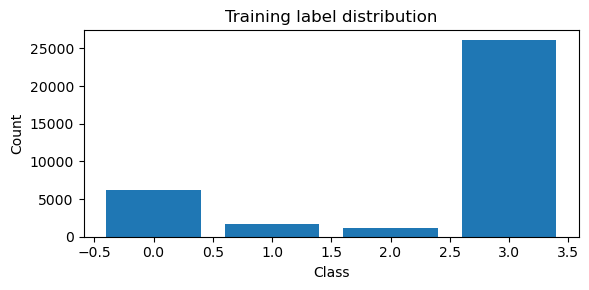

Class counts: [ 6222  1736  1101 26092]


In [6]:
counts = np.bincount(train_labels.astype(int))
plt.figure(figsize=(6, 3))
plt.bar(range(n_classes), counts)
plt.xlabel("Class"); plt.ylabel("Count")
plt.title("Training label distribution")
plt.tight_layout(); plt.show()
print("Class counts:", counts)

## 3. Data Augmentation: SpecAugment + Mixup

In [7]:
class SpecAugDataset(Dataset):
    """
    Applies SpecAugment (time & frequency masking) online during training.
    freq_mask_param: max number of mel bins to mask per mask (applied twice)
    time_mask_param: max number of time frames to mask per mask (applied twice)
    """
    def __init__(self, X, y, freq_mask_param=15, time_mask_param=25, augment=True):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def _spec_augment(self, mel):
        """mel: (1, F, T) tensor — modifies in-place and returns."""
        _, F, T = mel.shape

        # Frequency masking (×2)
        for _ in range(2):
            f = random.randint(0, self.freq_mask_param)
            f0 = random.randint(0, max(F - f, 0))
            mel[:, f0:f0 + f, :] = 0.0

        # Time masking (×2)
        for _ in range(2):
            t = random.randint(0, self.time_mask_param)
            t0 = random.randint(0, max(T - t, 0))
            mel[:, :, t0:t0 + t] = 0.0

        return mel

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]
        if self.augment:
            x = self._spec_augment(x)
        return x, y


def mixup_batch(x, y, n_classes, alpha=0.3):
    """
    Mixup: returns mixed inputs and soft one-hot targets.
    alpha controls the Beta distribution concentration.
    Returns: x_mixed (B,C,H,W), y_soft (B, n_classes)
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha, size=len(x))
        lam = np.maximum(lam, 1 - lam)         # always ≥ 0.5 so dominant label wins
    else:
        lam = np.ones(len(x))

    lam_t = torch.tensor(lam, dtype=torch.float32, device=x.device).view(-1, 1, 1, 1)
    idx   = torch.randperm(len(x), device=x.device)

    x_mix = lam_t * x + (1 - lam_t) * x[idx]

    # Soft targets
    y_oh  = F.one_hot(y, num_classes=n_classes).float()
    lam_y = torch.tensor(lam, dtype=torch.float32, device=x.device).view(-1, 1)
    y_mix = lam_y * y_oh + (1 - lam_y) * y_oh[idx]

    return x_mix, y_mix

print("SpecAugment + Mixup helpers defined.")

SpecAugment + Mixup helpers defined.


## 4. Model Architecture — Deeper CNN with 4 Stages

In [12]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.proj = (nn.Conv2d(in_ch, out_ch, 1, bias=False)
                     if in_ch != out_ch else nn.Identity())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.proj(x) + self.block(x))


class ImprovedCNN(nn.Module):
    def __init__(self, input_shape, n_classes, dropout=0.4):
        super().__init__()
        C, H, W = input_shape

        def _stage(in_ch, out_ch, pool):
            layers = [
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                ResBlock(out_ch, out_ch),
            ]
            if pool == "max":
                layers.append(nn.MaxPool2d(2))
            else:
                layers.append(nn.AdaptiveAvgPool2d((1, 1)))
            return nn.Sequential(*layers)

        self.stage1 = _stage(C,   32,  "max")
        self.stage2 = _stage(32,  64,  "max")
        self.stage3 = _stage(64,  128, "max")
        self.stage4 = _stage(128, 256, "gap")

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        return self.head(self.stage4(self.stage3(self.stage2(self.stage1(x)))))


def make_criterion(train_labels, device, label_smoothing=0.1):
    counts  = np.bincount(train_labels.astype(int))
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * len(counts)
    return nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32).to(device),
        label_smoothing=label_smoothing,
    )


model = ImprovedCNN(input_shape, n_classes).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 2,091,108


## 5. Training — Cosine Annealing LR + Mixup

In [13]:
BATCH_SIZE      = 128
NUM_EPOCHS      = 80
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
MIXUP_ALPHA     = 0.3      # Beta distribution parameter for Mixup
EARLY_STOP_PAT  = 15       # patience in epochs (on val macro-F1)
T_0             = 20       # CosineAnnealingWarmRestarts period (epochs)

train_ds = SpecAugDataset(train_mel, train_labels, augment=True)
val_ds   = SpecAugDataset(val_mel,   val_labels,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=256,         shuffle=False, num_workers=0)

criterion = make_criterion(train_labels, device, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=T_0, T_mult=1, eta_min=1e-5)

print("Setup complete. Starting training...")

Setup complete. Starting training...


In [15]:
train_losses, val_accs, val_f1s = [], [], []
best_val_f1    = 0.0
no_improve_ctr = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        Xb_mix, yb_soft = mixup_batch(Xb, yb, n_classes, alpha=MIXUP_ALPHA)

        optimizer.zero_grad()
        logits = model(Xb_mix)
        # Soft cross-entropy (works with mixed labels)
        log_probs = F.log_softmax(logits, dim=1)
        loss = -(yb_soft * log_probs).sum(dim=1).mean()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # gradient clipping
        optimizer.step()
        running_loss += loss.item()

    scheduler.step(epoch - 1)   # update LR
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ── Validate ────────────────────────────────────────────────────────────
    model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb = Xb.to(device)
            preds_all.extend(torch.argmax(model(Xb), dim=1).cpu().numpy())
            true_all.extend(yb.numpy())

    val_acc = accuracy_score(true_all, preds_all)
    val_f1  = f1_score(true_all, preds_all, average="macro", zero_division=0)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    # ── Save best (tracked on macro-F1) ────────────────────────────────────
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), MODEL_PATH)
        saved = "  ← saved"
        no_improve_ctr = 0
    else:
        saved = ""
        no_improve_ctr += 1

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Loss {avg_loss:.4f} | "
              f"Val Acc {val_acc:.4f} | Val F1 {val_f1:.4f} | LR {lr_now:.2e}{saved}")

    if no_improve_ctr >= EARLY_STOP_PAT:
        print(f"Early stopping at epoch {epoch} (no F1 improvement for {EARLY_STOP_PAT} epochs)")
        break

print(f"Training done. Best Val Macro-F1: {best_val_f1:.4f}")

Epoch   1/80 | Loss 0.4551 | Val Acc 0.8304 | Val F1 0.5139 | LR 1.00e-03  ← saved
Epoch   5/80 | Loss 0.3559 | Val Acc 0.8960 | Val F1 0.6144 | LR 9.05e-04
Epoch  15/80 | Loss 0.2903 | Val Acc 0.9369 | Val F1 0.7891 | LR 2.14e-04  ← saved
Epoch  20/80 | Loss 0.2712 | Val Acc 0.9407 | Val F1 0.7991 | LR 1.61e-05  ← saved
Epoch  25/80 | Loss 0.2968 | Val Acc 0.9150 | Val F1 0.7202 | LR 9.05e-04
Epoch  30/80 | Loss 0.2787 | Val Acc 0.9321 | Val F1 0.7601 | LR 5.82e-04
Epoch  35/80 | Loss 0.2541 | Val Acc 0.9377 | Val F1 0.7731 | LR 2.14e-04
Early stopping at epoch 35 (no F1 improvement for 15 epochs)
Training done. Best Val Macro-F1: 0.7991


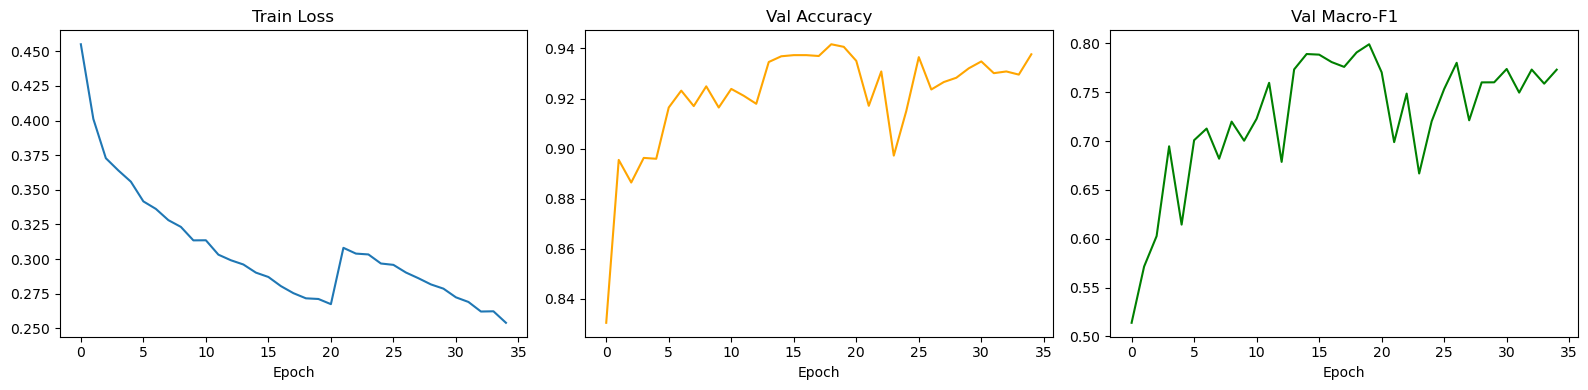

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(train_losses);        axes[0].set_title("Train Loss");   axes[0].set_xlabel("Epoch")
axes[1].plot(val_accs, "orange");  axes[1].set_title("Val Accuracy"); axes[1].set_xlabel("Epoch")
axes[2].plot(val_f1s,  "green");   axes[2].set_title("Val Macro-F1"); axes[2].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

## 6. Evaluation on Validation Set

In [18]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

preds_all, true_all = [], []
with torch.no_grad():
    for Xb, yb in val_loader:
        Xb = Xb.to(device)
        preds_all.extend(torch.argmax(model(Xb), dim=1).cpu().numpy())
        true_all.extend(yb.numpy())

print(classification_report(true_all, preds_all, zero_division=0))
print(f"Overall Accuracy : {accuracy_score(true_all, preds_all):.4f}")
print(f"Macro F1         : {f1_score(true_all, preds_all, average='macro', zero_division=0):.4f}")

              precision    recall  f1-score   support

           0       0.90      0.93      0.92      1572
           1       0.82      0.68      0.74       427
           2       0.64      0.49      0.56       341
           3       0.97      0.98      0.98      6406

    accuracy                           0.94      8746
   macro avg       0.83      0.77      0.80      8746
weighted avg       0.94      0.94      0.94      8746

Overall Accuracy : 0.9407
Macro F1         : 0.7991


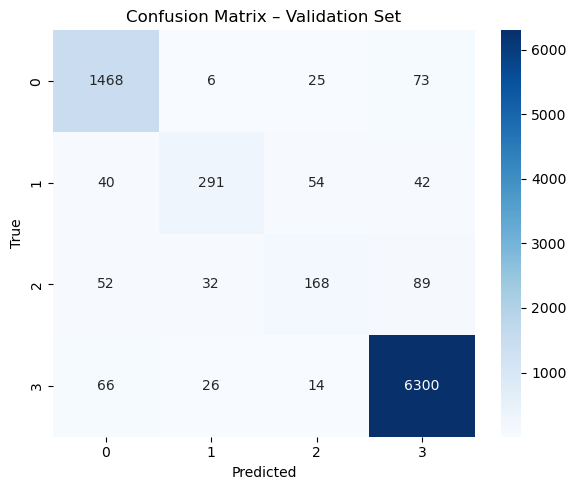

In [19]:
cm = confusion_matrix(true_all, preds_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix – Validation Set")
plt.tight_layout(); plt.show()

## 7. Multi-Seed Ensemble Training (Optional — Recommended)

In [24]:
# Train 2 additional models with different seeds, then majority-vote at inference.
# Comment out this cell if you are short on time; the single best model is already saved.

ENSEMBLE_SEEDS  = [0]
ENSEMBLE_PATHS  = [f"_ensemble_model_{s}.pth" for s in ENSEMBLE_SEEDS]

ensemble_models = []

for seed_idx, seed in enumerate(ENSEMBLE_SEEDS):
    print(f"══ Training ensemble member {seed_idx+1}/{len(ENSEMBLE_SEEDS)}  (seed={seed}) ══")
    set_seed(seed)

    m = ImprovedCNN(input_shape, n_classes).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=T_0, T_mult=1, eta_min=1e-5)

    best_f1_m = 0.0
    for epoch in range(1, 41):
        m.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            Xb_mix, yb_soft = mixup_batch(Xb, yb, n_classes, alpha=MIXUP_ALPHA)
            opt.zero_grad()
            logits = m(Xb_mix)
            log_probs = F.log_softmax(logits, dim=1)
            loss = -(yb_soft * log_probs).sum(dim=1).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sch.step(epoch - 1)

        m.eval()
        pa, ta = [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                pa.extend(torch.argmax(m(Xb.to(device)), dim=1).cpu().numpy())
                ta.extend(yb.numpy())
        f1 = f1_score(ta, pa, average="macro", zero_division=0)
        if f1 > best_f1_m:
            best_f1_m = f1
            torch.save(m.state_dict(), ENSEMBLE_PATHS[seed_idx])
        if epoch % 20 == 0:
            print(f"  Epoch {epoch} | F1 {f1:.4f} (best {best_f1_m:.4f})")

    m.load_state_dict(torch.load(ENSEMBLE_PATHS[seed_idx], map_location=device))
    ensemble_models.append(m)
    print(f"  Member {seed_idx+1} best val F1: {best_f1_m:.4f}")

print(f" Ensemble training complete.")

══ Training ensemble member 1/1  (seed=0) ══


KeyboardInterrupt: 

## 8. Test Predictions with TTA + Ensemble

In [29]:
!pip install librosa
import librosa
from scipy import stats

WINDOW_SIZE = 1.0
STEP_SIZE   = 0.5
N_FFT       = 1024
HOP_LENGTH  = 128

def normalise_mel(mel):
    """Per-sample z-score normalisation matching training."""
    m = mel.mean(); s = mel.std() + 1e-6
    return (mel - m) / s

def extract_mel_windows(h5_path):
    """Returns mel_windows (N, F, T) float32 and window_mid (N,) float64."""
    with h5py.File(h5_path, "r") as f:
        audio_data = f["audio_data"][()]
        audio_sr   = int(f["audio_sample_rate"][()])
        label_time = f["label_time"][()]

    audio_win = int(WINDOW_SIZE * audio_sr)
    audio_hop = int(STEP_SIZE   * audio_sr)
    n_windows = (len(audio_data) - audio_win) // audio_hop + 1

    mel_list, window_mid = [], []
    for i in range(n_windows):
        start   = i * audio_hop
        segment = audio_data[start:start + audio_win].astype(float)
        mel = librosa.feature.melspectrogram(
            y=segment, sr=audio_sr, n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel = librosa.power_to_db(mel, ref=np.max)
        mel = normalise_mel(mel)
        mel_list.append(mel.astype(np.float32))
        window_mid.append((start + audio_win / 2.0) / audio_sr)

    return np.stack(mel_list), np.array(window_mid), label_time


def predict_with_tta(models, mel_windows, batch_size=256, n_classes=4):
    """
    TTA: average softmax probs over original + time-reversed windows.
    Then ensemble over all provided models.
    Returns hard predictions (n_windows,).
    """
    # Two augmented views: original and time-flipped
    views = [
        torch.tensor(mel_windows[:, np.newaxis, :, :],       dtype=torch.float32),  # original
        torch.tensor(mel_windows[:, np.newaxis, :, ::-1].copy(), dtype=torch.float32),  # time-flip
    ]

    all_probs = []   # accumulate softmax probs

    for m in models:
        m.eval()
        for view in views:
            probs_view = []
            with torch.no_grad():
                for i in range(0, len(view), batch_size):
                    Xb = view[i:i + batch_size].to(device)
                    probs_view.append(F.softmax(m(Xb), dim=1).cpu().numpy())
            all_probs.append(np.concatenate(probs_view, axis=0))

    mean_probs    = np.mean(all_probs, axis=0)        # (n_windows, n_classes)
    window_preds  = mean_probs.argmax(axis=1)
    return window_preds


def map_preds_to_timestamps(window_preds, window_mid, label_time):
    indices      = np.searchsorted(window_mid, label_time)
    indices      = np.clip(indices, 0, len(window_preds) - 1)
    indices_prev = np.clip(indices - 1, 0, len(window_preds) - 1)
    dist_next    = np.abs(label_time - window_mid[indices])
    dist_prev    = np.abs(label_time - window_mid[indices_prev])
    indices      = np.where(dist_prev < dist_next, indices_prev, indices)
    return window_preds[indices]


print("TTA + ensemble inference helpers defined.")

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached soundfile-0.13.1-py2.py3-none-manylinux_2_28_x86_64.whl.metadata (16 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp312-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Using cached standard_aifc-3.13.0-py3-none-any.whl.metadata (969 bytes)
  Using cached standard_sunau-3.13.0-py3-none-any.whl.metadata (914 bytes)
  Using cached standard_chunk-3.13.0-py3-none-any.whl.metadata (860 bytes)
  Using cached audioop_lts-0.2.2-cp313-abi3-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (2.0 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached pooch-1.9.0-py3-none-any.whl (67 kB)
Using cached soundfile-0.13.1-py2.py3-none-manylinux_2_28_x86_64.whl (1.3 MB)
Using cached soxr-1.0.0-cp312-

In [30]:
fileLength = {
    "s11_trial1.csv": 7146625, "s11_trial2.csv": 6924950, "s11_trial3.csv": 7045450,
    "s12_trial1.csv": 7676148, "s12_trial2.csv": 7512373, "s12_trial3.csv": 7438071,
    "s13_trial1.csv": 7531470, "s13_trial2.csv": 8516621, "s13_trial3.csv": 7428557,
}

# Load the single best model (always available); add ensemble members if trained
best_model = ImprovedCNN(input_shape, n_classes).to(device)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

inference_models = [best_model]
print(f"Running inference with {len(inference_models)} model(s) + TTA")

test_files = sorted([f for f in os.listdir(FOLDER_TEST) if f.endswith(".h5")])
print(f"Found {len(test_files)} test files")

for fn in test_files:
    trial_name = os.path.splitext(fn)[0]
    csv_name   = trial_name + ".csv"
    out_path   = os.path.join(PRED_DIR, csv_name)
    h5_path    = os.path.join(FOLDER_TEST, fn)

    t0 = time.time()
    mel_windows, window_mid, label_time = extract_mel_windows(h5_path)
    window_preds = predict_with_tta(inference_models, mel_windows,
                                    n_classes=n_classes)
    preds = map_preds_to_timestamps(window_preds, window_mid, label_time)
    elapsed = time.time() - t0

    expected_len = fileLength.get(csv_name)
    status = "✅" if len(preds) == expected_len else "⚠ "
    print(f"{status} {csv_name}: {len(preds):,} / {expected_len:,} in {elapsed:.1f}s")

    np.savetxt(out_path, preds, fmt="%d", delimiter=",")
    print(f"   → saved to {out_path}")

print("All predictions written.")

Running inference with 1 model(s) + TTA
Found 9 test files
✅ s11_trial1.csv: 7,146,625 / 7,146,625 in 55.0s
   → saved to /home/jovyan/pc03-rspalimk/Data-Predictions/s11_trial1.csv
✅ s11_trial2.csv: 6,924,950 / 6,924,950 in 38.9s
   → saved to /home/jovyan/pc03-rspalimk/Data-Predictions/s11_trial2.csv
✅ s11_trial3.csv: 7,045,450 / 7,045,450 in 32.7s
   → saved to /home/jovyan/pc03-rspalimk/Data-Predictions/s11_trial3.csv
✅ s12_trial1.csv: 7,676,148 / 7,676,148 in 38.5s
   → saved to /home/jovyan/pc03-rspalimk/Data-Predictions/s12_trial1.csv
✅ s12_trial2.csv: 7,512,373 / 7,512,373 in 32.7s
   → saved to /home/jovyan/pc03-rspalimk/Data-Predictions/s12_trial2.csv
✅ s12_trial3.csv: 7,438,071 / 7,438,071 in 32.3s
   → saved to /home/jovyan/pc03-rspalimk/Data-Predictions/s12_trial3.csv
✅ s13_trial1.csv: 7,531,470 / 7,531,470 in 34.5s
   → saved to /home/jovyan/pc03-rspalimk/Data-Predictions/s13_trial1.csv
✅ s13_trial2.csv: 8,516,621 / 8,516,621 in 37.0s
   → saved to /home/jovyan/pc03-rspali

## 9. Format Validation

In [ ]:
all_ok = True

found    = set(os.listdir(PRED_DIR))
expected = set(fileLength.keys())
if expected != found:
    print(f"FAIL – missing files: {expected - found}")
    all_ok = False
else:
    print("PASS – all expected files present")

for csv_name, exp_len in fileLength.items():
    fp   = os.path.join(PRED_DIR, csv_name)
    data = np.loadtxt(fp, delimiter=",", dtype=int)
    ok   = True
    if data.shape != (exp_len,):
        print(f"FAIL {csv_name}: shape {data.shape} != ({exp_len},)"); ok = False
    if not np.all((data >= 0) & (data <= 3)):
        print(f"FAIL {csv_name}: values outside [0,3]"); ok = False
    if len(np.unique(data)) <= 1:
        print(f"FAIL {csv_name}: only one unique label"); ok = False
    if ok:
        dist = np.bincount(data, minlength=4)
        print(f"PASS {csv_name}  dist={dist}")
    else:
        all_ok = False

print()
if all_ok:
    print("✅  All format checks passed. Ready to commit and push!")
else:
    print("❌  Some checks failed. Review the warnings above.")